# Linear Regression

#### This notebook applies Linear Regression as a baseline model for predicting whether a basketball player is a good free throw shooter.

#### Since Linear Regression outputs continuous values, predictions are converted into binary classes using a threshold.

#### Linear Regression was used as a baseline model for comparison.

#### Although it is not designed for classification tasks, it provides insight into feature relationships. Predictions were converted into binary classes using a threshold of 0.5.

#### The model generally performs worse than classification models, which is expected.

#### Linear Regression is not inherently suitable for classification, 
#### but it was used as a baseline to compare performance with classification models.

In [255]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [256]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,G,GS,MP,FG%,3P%,2P%,eFG%,TRB,AST,STL,BLK,TOV,PF,FT%,GoodFT,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,78.0,78.0,36.1,0.519,0.200,0.523,0.520,7.4,4.6,2.2,1.8,3.6,2.7,0.787,1,False,False,True,False
1,82.0,82.0,38.3,0.502,0.000,0.504,0.502,14.5,1.8,1.0,1.3,3.7,2.6,0.719,0,False,False,False,False
2,82.0,82.0,35.8,0.505,0.333,0.506,0.506,8.8,2.4,1.1,0.7,2.0,2.3,0.775,1,False,False,False,False
3,82.0,82.0,34.2,0.523,0.000,0.525,0.523,7.2,1.1,0.9,0.9,2.1,3.2,0.787,1,False,False,True,False
4,82.0,82.0,36.2,0.482,0.194,0.489,0.484,3.4,4.8,2.4,0.5,2.2,2.0,0.788,1,False,True,False,False


In [257]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [258]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [259]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [260]:
y_pred_continuous = model.predict(X_test)

In [261]:
y_pred = (y_pred_continuous > 0.5).astype(int)

In [262]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9158001521683997


In [263]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90      1825
           1       0.88      0.98      0.93      2118

    accuracy                           0.92      3943
   macro avg       0.93      0.91      0.91      3943
weighted avg       0.92      0.92      0.92      3943



In [264]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1534  291]
 [  41 2077]]


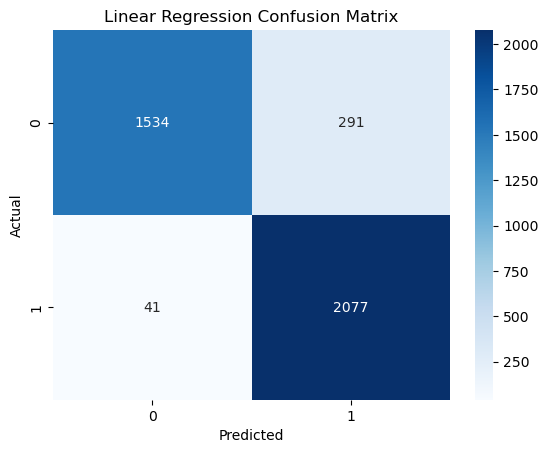

In [265]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear Regression Confusion Matrix")
plt.show()

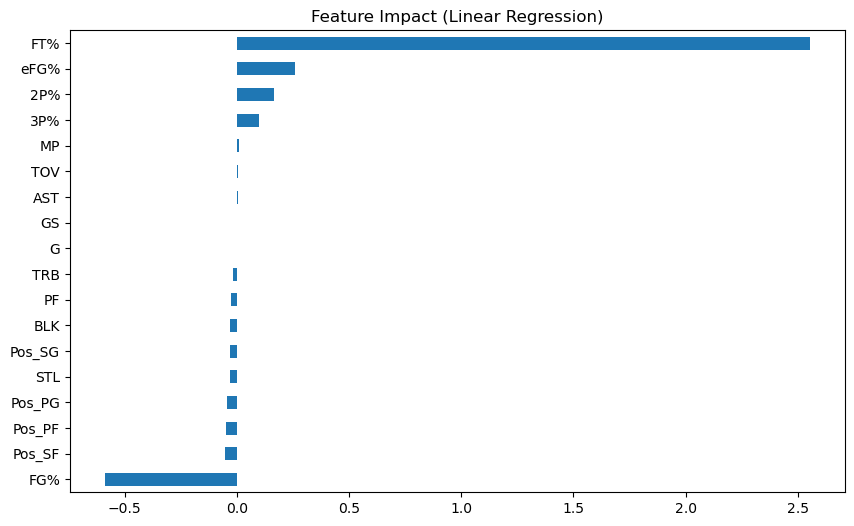

In [266]:
coefficients = pd.Series(model.coef_, index=X.columns)

coefficients.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Impact (Linear Regression)")
plt.show()